# Convergence Diagnostics and Model Comparison

This notebook covers two complementary use cases of particle-filter diagnostics:

1. **Convergence**: how does the Monte Carlo error decay with $N$?
   We verify the textbook $\mathcal{O}(1/\sqrt{N})$ rate for both the filtered-state
   RMSE and the variance of the log-likelihood estimator, and we use the variance to
   pick a minimum $N$ for downstream inference (PMMH, SMC${}^2$).

2. **Model comparison**: using the unbiased particle-filter estimate of
   $p(y_{1:T} \mid M)$ to form sequential log Bayes factors between competing SV
   specifications.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import time

sys.path.insert(0, str(Path.cwd().parents[2]))

from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.core.config import PFConfig
from particlefilterbox.filters.bootstrap import BootstrapPF

plt.rcParams['figure.figsize'] = (12, 4.5)
plt.rcParams['figure.dpi'] = 100
np.set_printoptions(suppress=True, precision=4)
print('Imports OK')

Imports OK


In [2]:
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df = pd.read_csv(data_path)
h_true = df['h_true'].values
y_obs = df['y_obs'].values
T = len(df)
print(f'T = {T}, y range = [{y_obs.min():.2f}, {y_obs.max():.2f}]')

T = 1000, y range = [-2.46, 1.90]


## Models

We use three SV specifications for this study:

- **SV (true)** — Gaussian log-volatility with $\mu=-1.0,\ \phi=0.97,\ \sigma=0.15$,
  matching the data-generating process of `simulated_sv.csv`.
- **SV misspecified** — same form but with wrong persistence / volatility:
  $\mu=0.0,\ \phi=0.50,\ \sigma=0.80$.
- **GARCH-like** — Gaussian observations with a recursive variance process
  $\sigma_t^2 = \omega + \alpha\, y_{t-1}^2 + \beta\, \sigma_{t-1}^2$,
  wrapped as a particle-filter model with a 1-D deterministic state plus a small
  stochastic perturbation so the particle-filter machinery applies.


In [3]:
class SVModel(ParticleFilterModel):
    k_states = 1
    k_obs = 1

    def __init__(self, mu=-1.0, phi=0.97, sigma=0.15) -> None:
        self.mu, self.phi, self.sigma = mu, phi, sigma

    @property
    def params(self):
        return {'mu': self.mu, 'phi': self.phi, 'sigma': self.sigma}

    def initial_distribution(self, n, rng):
        std = self.sigma / np.sqrt(1.0 - self.phi**2)
        return rng.normal(self.mu, std, size=(n, 1))

    def transition(self, particles, t, rng):
        h = particles[:, 0]
        return (self.mu + self.phi * (h - self.mu)
                + self.sigma * rng.standard_normal(len(h))).reshape(-1, 1)

    def log_observation_likelihood(self, particles, y_t, t):
        h = particles[:, 0]
        vol = np.exp(h / 2.0)
        return -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_t[0] / vol) ** 2


class GARCHLikeModel(ParticleFilterModel):
    """GARCH(1,1) variance driven by a deterministic recursion on the last obs
    plus a small stochastic log-volatility component so particles spread."""
    k_states = 1
    k_obs = 1

    def __init__(self, omega=0.05, alpha=0.10, beta=0.85, sigma_jitter=0.05) -> None:
        self.omega, self.alpha, self.beta = omega, alpha, beta
        self.sigma_jitter = sigma_jitter
        self._last_y = 0.0
        self._last_var = omega / max(1e-8, 1.0 - alpha - beta)

    @property
    def params(self):
        return {'omega': self.omega, 'alpha': self.alpha, 'beta': self.beta}

    def initial_distribution(self, n, rng):
        v0 = self._last_var
        lh0 = np.log(v0)
        return rng.normal(lh0, self.sigma_jitter, size=(n, 1))

    def transition(self, particles, t, rng):
        # Deterministic GARCH recursion on the variance, using previous observation
        # as a proxy for the shock. Particles carry small stochastic deviations.
        lh = particles[:, 0]
        v_det = self.omega + self.alpha * self._last_y**2 + self.beta * np.exp(lh)
        v_det = np.clip(v_det, 1e-8, None)
        lh_new = np.log(v_det) + self.sigma_jitter * rng.standard_normal(len(lh))
        return lh_new.reshape(-1, 1)

    def log_observation_likelihood(self, particles, y_t, t):
        self._last_y = float(y_t[0])
        v = np.exp(particles[:, 0])
        return -0.5 * np.log(2.0 * np.pi * v) - 0.5 * y_t[0]**2 / v

print('Models defined')

Models defined


## 1. Convergence: RMSE vs N

We run the Bootstrap PF at increasing $N$ and measure two quantities:

- **Filtering RMSE** — root mean squared error of the filtered mean $\hat h_t^{(N)}$
  against the simulated ground truth $h_t$. This equals
  $\sqrt{\mathrm{bias}^2 + \mathrm{var}(N)}$ and is bounded below by the
  (non-zero) posterior uncertainty, so for large $N$ it plateaus.
- **Monte Carlo RMSE** — error of $\hat h_t^{(N)}$ against a *gold-standard*
  filtered mean computed with $N_{\mathrm{ref}} = 20\,000$. This strips out the
  bias and should decay as $1/\sqrt{N}$.


In [4]:
def run_pf(model, y, N, seed, ess_threshold=0.5):
    cfg = PFConfig(n_particles=N, resampling='systematic',
                   ess_threshold=ess_threshold, seed=seed)
    pf = BootstrapPF(model, cfg)
    res = pf.filter(y)
    return res

# Gold-standard filter mean (averaged over a few runs) for MC-only error
N_REF = 20000
N_REF_REPS = 3
ref_mean = np.zeros(T)
for rep in range(N_REF_REPS):
    ref_mean += run_pf(SVModel(), y_obs, N_REF, seed=99 + rep).filtered_means[:, 0]
ref_mean /= N_REF_REPS
ll_ref = np.mean([run_pf(SVModel(), y_obs, N_REF, seed=99 + rep).log_likelihood
                  for rep in range(N_REF_REPS)])
print(f'Gold-standard: N_ref={N_REF}, logL = {ll_ref:.2f}')

N_list = [50, 100, 200, 500, 1000, 2000, 5000]
N_REPS = 10

rmse_truth, rmse_mc, rmse_std_mc, ll_mean, ll_std, times = [], [], [], [], [], []
for N in N_list:
    r_truth, r_mc, lls = [], [], []
    t0 = time.time()
    for rep in range(N_REPS):
        res = run_pf(SVModel(), y_obs, N, seed=1000 + rep)
        fm = res.filtered_means[:, 0]
        r_truth.append(np.sqrt(np.mean((fm - h_true) ** 2)))
        r_mc.append(np.sqrt(np.mean((fm - ref_mean) ** 2)))
        lls.append(res.log_likelihood)
    elapsed = time.time() - t0
    rmse_truth.append(np.mean(r_truth))
    rmse_mc.append(np.mean(r_mc))
    rmse_std_mc.append(np.std(r_mc))
    ll_mean.append(np.mean(lls))
    ll_std.append(np.std(lls))
    times.append(elapsed / N_REPS)
    print(f'N={N:>5d}  RMSE_truth={np.mean(r_truth):.4f}'
          f'  RMSE_MC={np.mean(r_mc):.4f} +/- {np.std(r_mc):.4f}'
          f'  logL_std={np.std(lls):.3f}'
          f'  t/run={elapsed/N_REPS:.2f}s')

conv = pd.DataFrame({
    'N': N_list,
    'RMSE vs truth': rmse_truth,
    'RMSE vs gold (MC)': rmse_mc,
    'logL mean': ll_mean, 'logL std': ll_std,
    'time per run (s)': times,
}).round(4)
conv

Gold-standard: N_ref=20000, logL = -812.91


N=   50  RMSE_truth=0.4582  RMSE_MC=0.0845 +/- 0.0057  logL_std=2.757  t/run=0.22s


N=  100  RMSE_truth=0.4539  RMSE_MC=0.0555 +/- 0.0046  logL_std=1.228  t/run=0.22s


N=  200  RMSE_truth=0.4569  RMSE_MC=0.0410 +/- 0.0051  logL_std=0.643  t/run=0.21s


N=  500  RMSE_truth=0.4536  RMSE_MC=0.0263 +/- 0.0016  logL_std=0.379  t/run=0.16s


N= 1000  RMSE_truth=0.4541  RMSE_MC=0.0177 +/- 0.0010  logL_std=0.322  t/run=0.28s


N= 2000  RMSE_truth=0.4532  RMSE_MC=0.0131 +/- 0.0010  logL_std=0.242  t/run=0.35s


N= 5000  RMSE_truth=0.4534  RMSE_MC=0.0084 +/- 0.0009  logL_std=0.161  t/run=0.50s


,N,RMSE vs truth,RMSE vs gold (MC),logL mean,logL std,time per run (s)
0,50,0.4582,0.0845,-813.3956,2.7575,0.2204
1,100,0.4539,0.0555,-813.2660,1.2277,0.2195
2,200,0.4569,0.0410,-813.7477,0.6434,0.2139
3,500,0.4536,0.0263,-813.2167,0.3791,0.1613
4,1000,0.4541,0.0177,-812.9751,0.3218,0.2817
5,2000,0.4532,0.0131,-812.8438,0.2420,0.3507
6,5000,0.4534,0.0084,-812.8897,0.1609,0.4992


## 2. Empirical convergence rate (log-log)

Overlay the fitted slope against the theoretical $-1/2$ reference. A slope of
$\approx -0.5$ for the RMSE-vs-N curve confirms the CLT-based rate.


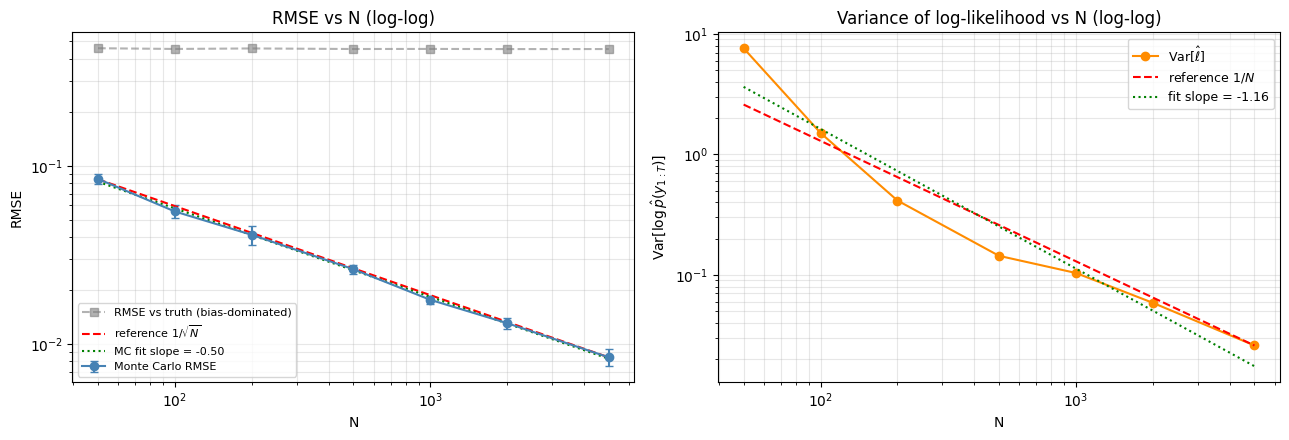

Fitted MC-RMSE slope = -0.497  (theory: -0.5)
Fitted logL-var slope = -1.159  (theory: -1.0)


In [5]:
N_arr = np.array(N_list, dtype=float)
rmse_truth_arr = np.array(rmse_truth)
rmse_mc_arr = np.array(rmse_mc)
rmse_mc_std_arr = np.array(rmse_std_mc)

# Fit slopes in log-log space
slope_mc, inter_mc = np.polyfit(np.log(N_arr), np.log(rmse_mc_arr), 1)
ll_var = np.array(ll_std) ** 2
slope_ll, inter_ll = np.polyfit(np.log(N_arr), np.log(ll_var), 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.errorbar(N_arr, rmse_mc_arr, yerr=rmse_mc_std_arr, fmt='o-',
            color='steelblue', capsize=3, label='Monte Carlo RMSE')
ax.plot(N_arr, rmse_truth_arr, 's--', color='gray', alpha=0.6,
        label='RMSE vs truth (bias-dominated)')
c = rmse_mc_arr[-1] * np.sqrt(N_arr[-1])
ax.plot(N_arr, c / np.sqrt(N_arr), 'r--', label=r'reference $1/\sqrt{N}$')
ax.plot(N_arr, np.exp(inter_mc) * N_arr**slope_mc, 'g:',
        label=f'MC fit slope = {slope_mc:.2f}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N'); ax.set_ylabel('RMSE')
ax.set_title('RMSE vs N (log-log)')
ax.legend(fontsize=8, loc='lower left'); ax.grid(alpha=0.3, which='both')

ax = axes[1]
ax.plot(N_arr, ll_var, 'o-', color='darkorange', label=r'$\mathrm{Var}[\hat\ell]$')
c2 = ll_var[-1] * N_arr[-1]
ax.plot(N_arr, c2 / N_arr, 'r--', label=r'reference $1/N$')
ax.plot(N_arr, np.exp(inter_ll) * N_arr**slope_ll, 'g:',
        label=f'fit slope = {slope_ll:.2f}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N'); ax.set_ylabel(r'Var[$\log \hat p(y_{1:T})$]')
ax.set_title('Variance of log-likelihood vs N (log-log)')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()
print(f'Fitted MC-RMSE slope = {slope_mc:.3f}  (theory: -0.5)')
print(f'Fitted logL-var slope = {slope_ll:.3f}  (theory: -1.0)')

## 3. Filtered-mean shrinkage across N

A second view of convergence: run the filter once at each N and plot the filtered
log-volatility against the ground truth. Larger N clearly sticks closer to $h_t$,
with noticeably smaller oscillations in low-ESS regions.


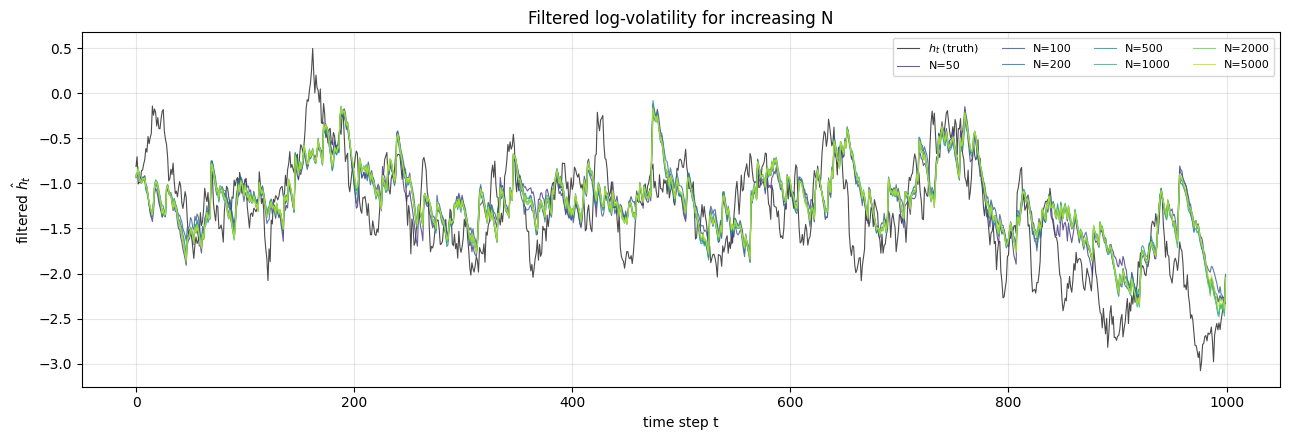

In [6]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(h_true, 'k-', lw=0.8, alpha=0.7, label='$h_t$ (truth)')
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(N_list)))
for N, c in zip(N_list, colors):
    res = run_pf(SVModel(), y_obs, N, seed=2024)
    ax.plot(res.filtered_means[:, 0], color=c, lw=0.8, alpha=0.8, label=f'N={N}')
ax.set_xlabel('time step t')
ax.set_ylabel('filtered $\\hat h_t$')
ax.set_title('Filtered log-volatility for increasing N')
ax.legend(fontsize=8, ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Log-likelihood variance at fixed N

We run the particle filter 50 times at $N=500$ and $N=2000$ to get a clean Monte
Carlo picture of $\log \hat p(y_{1:T})$. The variance should shrink by a factor
of $2000/500 = 4$ (std halves).


In [7]:
def logL_samples(model_factory, y, N, n_reps, seed0=777):
    out = np.empty(n_reps)
    for rep in range(n_reps):
        res = run_pf(model_factory(), y, N, seed=seed0 + rep)
        out[rep] = res.log_likelihood
    return out

N_REPS_VAR = 50
logL_500  = logL_samples(SVModel, y_obs, 500,  N_REPS_VAR)
logL_2000 = logL_samples(SVModel, y_obs, 2000, N_REPS_VAR)

print(f'N=500 : mean logL = {logL_500.mean():.2f}, std = {logL_500.std():.2f}')
print(f'N=2000: mean logL = {logL_2000.mean():.2f}, std = {logL_2000.std():.2f}')
print(f'std ratio (500/2000) = {logL_500.std()/logL_2000.std():.2f}  (expected ~2.0)')

N=500 : mean logL = -813.09, std = 0.56
N=2000: mean logL = -812.96, std = 0.27
std ratio (500/2000) = 2.09  (expected ~2.0)


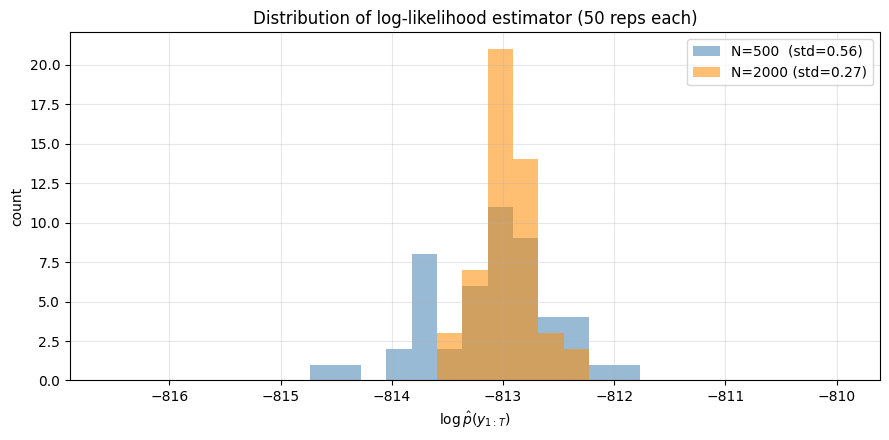

N=  500: Var[log-lik] = 0.32 -> PMMH ready? yes
N= 2000: Var[log-lik] = 0.07 -> PMMH ready? yes


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(min(logL_500.min(), logL_2000.min()) - 2,
                   max(logL_500.max(), logL_2000.max()) + 2, 30)
ax.hist(logL_500, bins=bins, alpha=0.55, color='steelblue',
        label=f'N=500  (std={logL_500.std():.2f})')
ax.hist(logL_2000, bins=bins, alpha=0.55, color='darkorange',
        label=f'N=2000 (std={logL_2000.std():.2f})')
ax.set_xlabel(r'$\log \hat p(y_{1:T})$')
ax.set_ylabel('count')
ax.set_title(f'Distribution of log-likelihood estimator ({N_REPS_VAR} reps each)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Rule of thumb for PMMH: Var[log-lik] ~ 1 for efficient chains (Pitt et al. 2012)
for N, std in [(500, logL_500.std()), (2000, logL_2000.std())]:
    print(f'N={N:>5d}: Var[log-lik] = {std**2:.2f} -> PMMH ready? {"yes" if std**2 <= 2.0 else "marginal" if std**2 <= 5.0 else "no"}')

## 5. Model comparison via particle-filter marginal likelihood

For each candidate model $M_k$ the particle filter returns an unbiased estimate of
$p(y_{1:T} \mid M_k) = \prod_t p(y_t \mid y_{1:t-1}, M_k)$. The log Bayes factor
between $M_1$ and $M_2$ at time $t$ is the cumulative sum of the per-step
log-predictive differences:

$$\log \mathrm{BF}_{1,2}(t) = \sum_{s \le t} \log \frac{\hat p(y_s \mid y_{1:s-1}, M_1)}{\hat p(y_s \mid y_{1:s-1}, M_2)}.$$

To reduce Monte Carlo noise we average over several particle-filter runs per model.


In [9]:
N_CMP = 2000
N_REPS_CMP = 10

def avg_incremental_logL(model_factory, y, N, n_reps, seed0):
    inc = None
    ll_totals = []
    for rep in range(n_reps):
        res = run_pf(model_factory(), y, N, seed=seed0 + rep)
        if inc is None:
            inc = res.log_likelihoods.copy()
        else:
            inc = inc + res.log_likelihoods
        ll_totals.append(res.log_likelihood)
    inc /= n_reps
    return inc, np.array(ll_totals)

inc_sv_true, ll_sv_true = avg_incremental_logL(
    lambda: SVModel(mu=-1.0, phi=0.97, sigma=0.15), y_obs, N_CMP, N_REPS_CMP, seed0=1)

inc_sv_wrong, ll_sv_wrong = avg_incremental_logL(
    lambda: SVModel(mu=0.0, phi=0.50, sigma=0.80), y_obs, N_CMP, N_REPS_CMP, seed0=101)

inc_garch, ll_garch = avg_incremental_logL(
    lambda: GARCHLikeModel(omega=0.05, alpha=0.10, beta=0.85), y_obs, N_CMP, N_REPS_CMP, seed0=201)

print(f'log p(y|SV_true)  = {ll_sv_true.mean():.2f} +/- {ll_sv_true.std():.2f}')
print(f'log p(y|SV_wrong) = {ll_sv_wrong.mean():.2f} +/- {ll_sv_wrong.std():.2f}')
print(f'log p(y|GARCH)    = {ll_garch.mean():.2f} +/- {ll_garch.std():.2f}')

log p(y|SV_true)  = -812.95 +/- 0.21
log p(y|SV_wrong) = -1005.37 +/- 0.34
log p(y|GARCH)    = -885.49 +/- 0.05


## 6. Per-step log predictive difference

Before cumulating, it helps to look at the *incremental* log Bayes factor per time
step. Spikes mark observations where one model assigns dramatically higher
predictive density than the other.


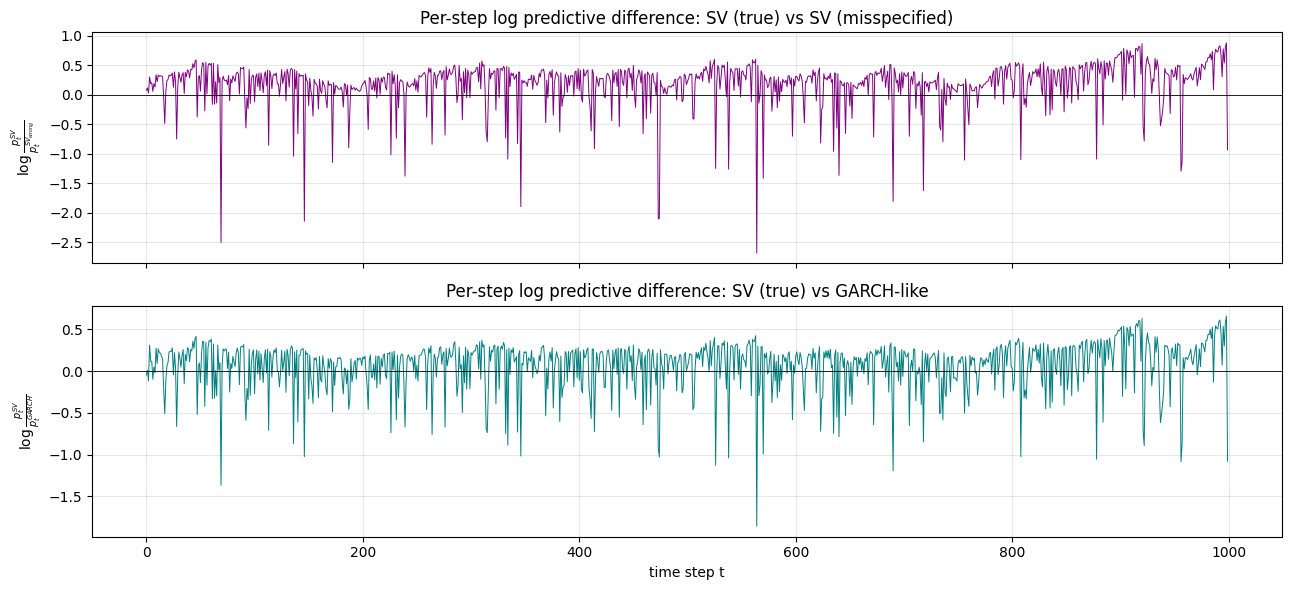

mean per-step advantage (true vs wrong) = +0.1924
mean per-step advantage (true vs garch) = +0.0725


In [10]:
diff_true_wrong = inc_sv_true - inc_sv_wrong
diff_true_garch = inc_sv_true - inc_garch

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax = axes[0]
ax.plot(diff_true_wrong, color='purple', lw=0.7)
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel(r'$\log \frac{p_t^{SV}}{p_t^{SV_{wrong}}}$')
ax.set_title('Per-step log predictive difference: SV (true) vs SV (misspecified)')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(diff_true_garch, color='teal', lw=0.7)
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('time step t')
ax.set_ylabel(r'$\log \frac{p_t^{SV}}{p_t^{GARCH}}$')
ax.set_title('Per-step log predictive difference: SV (true) vs GARCH-like')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'mean per-step advantage (true vs wrong) = {diff_true_wrong.mean():+.4f}')
print(f'mean per-step advantage (true vs garch) = {diff_true_garch.mean():+.4f}')

## 7. Sequential log Bayes factors

Plot the running sums; positive slope means evidence is accumulating in favor of
the first model.


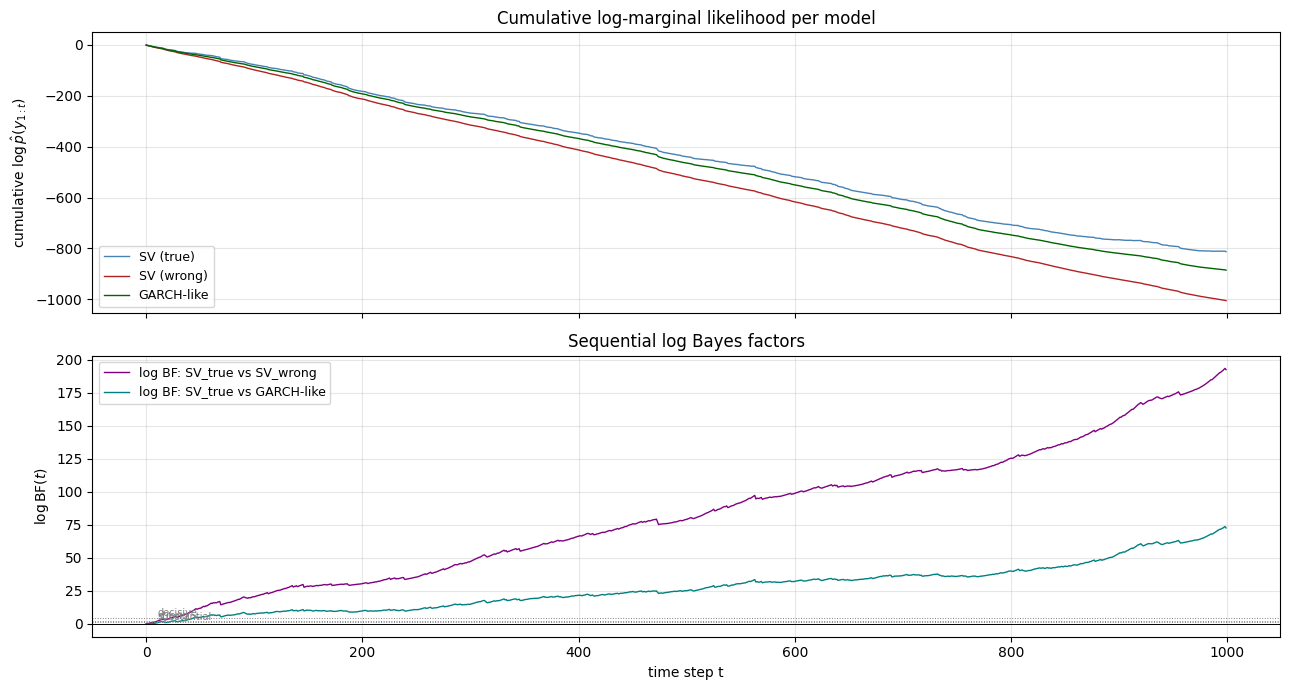

Final log BF (true vs wrong) = +192.42
Final log BF (true vs GARCH) = +72.55


In [11]:
cum_sv_true  = np.cumsum(inc_sv_true)
cum_sv_wrong = np.cumsum(inc_sv_wrong)
cum_garch    = np.cumsum(inc_garch)

log_bf_true_vs_wrong = cum_sv_true - cum_sv_wrong
log_bf_true_vs_garch = cum_sv_true - cum_garch

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(cum_sv_true,  label='SV (true)',  color='steelblue', lw=1)
ax.plot(cum_sv_wrong, label='SV (wrong)', color='firebrick', lw=1)
ax.plot(cum_garch,    label='GARCH-like', color='darkgreen', lw=1)
ax.set_ylabel(r'cumulative $\log \hat p(y_{1:t})$')
ax.set_title('Cumulative log-marginal likelihood per model')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(log_bf_true_vs_wrong, label='log BF: SV_true vs SV_wrong', color='purple', lw=1)
ax.plot(log_bf_true_vs_garch, label='log BF: SV_true vs GARCH-like', color='teal', lw=1)
ax.axhline(0, color='black', lw=0.7)
# Jeffreys scale guides
for thr, tag in [(1.0, 'substantial'), (2.3, 'strong'), (4.6, 'decisive')]:
    ax.axhline(thr, color='gray', ls=':', lw=0.7)
    ax.text(T * 0.01, thr, tag, fontsize=7, va='bottom', color='gray')
ax.set_xlabel('time step t')
ax.set_ylabel(r'$\log \mathrm{BF}(t)$')
ax.set_title('Sequential log Bayes factors')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final log BF (true vs wrong) = {log_bf_true_vs_wrong[-1]:+.2f}')
print(f'Final log BF (true vs GARCH) = {log_bf_true_vs_garch[-1]:+.2f}')

## 8. Model-evidence table

Summary of the log-marginal likelihood with Monte Carlo uncertainty. Larger is
better; use the Jeffreys scale to judge the difference ($\log \mathrm{BF} > 2.3$
is strong evidence, $> 4.6$ is decisive).


In [12]:
def ll_summary(name, ll_samples):
    return {
        'model': name,
        'log p(y|M) mean': ll_samples.mean(),
        'log p(y|M) std':  ll_samples.std(),
        'BIC-like rank':   ll_samples.mean(),
    }

evidence = pd.DataFrame([
    ll_summary('SV (true params)',       ll_sv_true),
    ll_summary('SV (misspecified)',      ll_sv_wrong),
    ll_summary('GARCH-like',             ll_garch),
]).sort_values('log p(y|M) mean', ascending=False).reset_index(drop=True)
evidence = evidence.round(3)
evidence

,model,log p(y|M) mean,log p(y|M) std,BIC-like rank
0,SV (true params),-812.946,0.208,-812.946
1,GARCH-like,-885.494,0.046,-885.494
2,SV (misspecified),-1005.366,0.338,-1005.366


## 9. Guidelines

**Picking N for filtering vs for parameter estimation**

- *Filtering only* — choose N such that $\mathrm{ESS}_t \ge N/10$ for essentially
  every step. For the SV dataset used here, $N \approx 500$ is already enough.
- *Log-likelihood for model comparison* — target $\mathrm{Var}[\log \hat\ell] \le 2$
  to keep log Bayes factor error small. In practice this means $N$ at least a few
  thousand for datasets with $T \sim 10^3$.
- *PMMH / correlated pseudo-marginal* — Pitt, Silva, Giordani & Kohn (2012) give the
  textbook target $\mathrm{Var}[\log \hat\ell] \approx 1$; $N$ should grow roughly
  linearly in $T$.

**Reporting**

- Always report log-likelihood as *mean $\pm$ std over several particle-filter runs*;
  a single-run number is noisy and can flip Bayes-factor signs.
- Sequential $\log \mathrm{BF}(t)$ plots reveal *when* the data discriminates the
  models: a flat trajectory at the start followed by a sharp climb usually indicates
  that tail events (extreme $y_t$) carry most of the information.
